[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AaronGrace978/Automata/blob/main/notebooks/train_words_colab.ipynb)

# The body speaks — fine-tune the diatom on an A100

One rule, every cell. This notebook takes the grown-frustule rule (`assets/checkpoint.pt`) and fine-tunes it so the **same cells rebuild themselves as words** written into the silica template channel, then return to glass when the template clears. It then exports the weights the desktop app (`electron/`) runs.

What happens:

1. Clone the repo at a release tag, install, check the GPU.
2. **Phase 1** — `train_morph`: half frustule tasks, half word tasks, organisms handed new tasks without resetting their bodies (frustule→word, word→word, word→frustule).
3. **Phase 2** — polish: more frustule tasks and longer rollouts so the body between words is a sharp frustule and the lobes withdraw cleanly.
4. Proof strip and GIF: frustule → GLASS → HOLDS → frustule, grown by the rule.
5. Export `assets/checkpoint_words.pt` + `web/weights.js` and download them.

On an A100 the whole run is minutes. **Runtime → Change runtime type → GPU.**


In [1]:
import subprocess, torch
print(subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                     capture_output=True, text=True).stdout.strip() or 'no nvidia-smi')
assert torch.cuda.is_available(), 'Runtime -> Change runtime type -> GPU (A100)'
print('torch', torch.__version__, '| cuda', torch.version.cuda)

NVIDIA A100-SXM4-80GB, 81920 MiB
torch 2.11.0+cu128 | cuda 12.8


In [2]:
import os
REPO = 'https://github.com/AaronGrace978/Automata.git'
REF = 'v1.7.1'  #@param {type:"string"}
if not os.path.exists('/content/Automata'):
    !git clone --quiet --branch $REF --depth 1 $REPO /content/Automata
%cd /content/Automata
!pip -q install -r requirements.txt
# Training words are rendered with DejaVu Sans Bold; the desktop app renders with the same face.
!test -f /usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf || (apt-get -qq update && apt-get -qq install -y fonts-dejavu-core)
!python -c "from nca.glyph import _font_path; print('font:', _font_path())"
!python -m pytest -q tests/test_body_parity.py::test_glyph_layout_rules tests/test_body_parity.py::test_morph_training_step_runs

Note: switching to '9f5b00d65d1104e853a96ea3ef0b7f85a872b9b6'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

/content/Automata
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
S

## Settings

`SIZE` must stay **48** to match the desktop app (`electron/renderer/app.js`, `SIZE = 48`) unless you change it there too. A 48-cell body holds one word at a time (up to 7 letters per line; longer words split in two). `WORD_PROB` is the share of word tasks in phase 1; phase 2 lowers it to give the frustule back its detail.

A100 defaults below: batch 32, pool 256, 12k + 4k steps. Loss is MSE on RGBA after a random 24–48 (phase 2: 32–64) step rollout; expect it to hover around 0.02–0.05 with noise, not to fall monotonically, because a third of every batch has just been handed a new task.

In [3]:
STEPS = 12000        #@param {type:"integer"}
POLISH_STEPS = 4000  #@param {type:"integer"}
BATCH = 32           #@param {type:"integer"}
POOL = 256           #@param {type:"integer"}
SIZE = 48            #@param {type:"integer"}
WORD_PROB = 0.5      #@param {type:"number"}
LR = 1e-3            #@param {type:"number"}
print(f'{STEPS}+{POLISH_STEPS} steps, batch {BATCH}, pool {POOL}, {SIZE}x{SIZE} body')

12000+4000 steps, batch 32, pool 256, 48x48 body


## Phase 1 — the frustule learns to become words

In [4]:
!python scripts/train_words.py --init assets/checkpoint.pt --out assets/checkpoint_words.pt \
  --steps $STEPS --batch $BATCH --pool $POOL --size $SIZE --word-prob $WORD_PROB --lr $LR \
  --rollout-min 24 --rollout-max 48 --device cuda --log-every 250 --save-every 1000

starting from assets/checkpoint.pt
[250/12000] loss=0.02353
[500/12000] loss=0.03535
[750/12000] loss=0.03733
[1000/12000] loss=0.03130
[1250/12000] loss=0.04477
[1500/12000] loss=0.03182
[1750/12000] loss=0.03213
[2000/12000] loss=0.03359
[2250/12000] loss=0.02285
[2500/12000] loss=0.04375
[2750/12000] loss=0.03881
[3000/12000] loss=0.02543
[3250/12000] loss=0.03636
[3500/12000] loss=0.03219
[3750/12000] loss=0.03706
[4000/12000] loss=0.02360
[4250/12000] loss=0.03514
[4500/12000] loss=0.03917
[4750/12000] loss=0.02839
[5000/12000] loss=0.03056
[5250/12000] loss=0.03441
[5500/12000] loss=0.04302
[5750/12000] loss=0.04130
[6000/12000] loss=0.04851
[6250/12000] loss=0.03081
[6500/12000] loss=0.02744
[6750/12000] loss=0.02965
[7000/12000] loss=0.03438
[7250/12000] loss=0.03458
[7500/12000] loss=0.03643
[7750/12000] loss=0.03664
[8000/12000] loss=0.02462
[8250/12000] loss=0.04473
[8500/12000] loss=0.03577
[8750/12000] loss=0.03806
[9000/12000] loss=0.02683
[9250/12000] loss=0.02522
[9500/

## Phase 2 — polish the frustule between words

In [5]:
!python scripts/train_words.py --init assets/checkpoint_words.pt --out assets/checkpoint_words.pt \
  --steps $POLISH_STEPS --batch $BATCH --pool $POOL --size $SIZE --word-prob 0.35 --lr 5e-4 \
  --rollout-min 32 --rollout-max 64 --device cuda --log-every 250 --save-every 1000

starting from assets/checkpoint_words.pt
[250/4000] loss=0.03099
[500/4000] loss=0.03246
[750/4000] loss=0.04483
[1000/4000] loss=0.03595
[1250/4000] loss=0.03906
[1500/4000] loss=0.03479
[1750/4000] loss=0.04605
[2000/4000] loss=0.03144
[2250/4000] loss=0.03814
[2500/4000] loss=0.03585
[2750/4000] loss=0.04058
[3000/4000] loss=0.05038
[3250/4000] loss=0.03089
[3500/4000] loss=0.04302
[3750/4000] loss=0.03708
[4000/4000] loss=0.03327
saved assets/checkpoint_words.pt


## Proof

Grow the frustule for 64 steps, write each word into the template for 40 + 24 steps, clear it for 40. Left to right: frustule, each word, frustule again. All of it is the rule; nothing is drawn.

saved assets/words.gif (233 frames)
saved assets/demo/words_strip.png: frustule -> GLASS -> HOLDS -> frustule


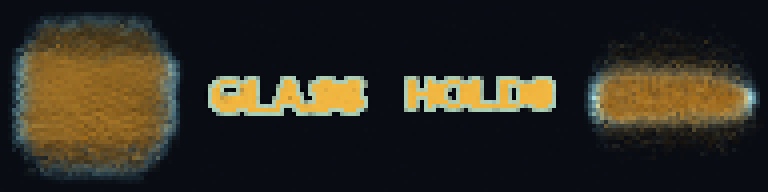

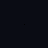

In [6]:
!python scripts/demo_words.py --checkpoint assets/checkpoint_words.pt --text "glass holds"
from IPython.display import Image, display
display(Image('assets/demo/words_strip.png'))
display(Image('assets/words.gif'))

saved /content/say.gif (297 frames)
saved /content/say.png: frustule -> I -> HEARD -> YOU -> frustule


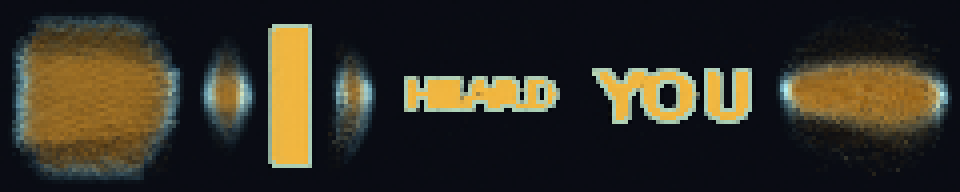

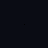

In [7]:
TEXT = 'I heard you'  #@param {type:"string"}
!python scripts/demo_words.py --checkpoint assets/checkpoint_words.pt --text "$TEXT" --gif /content/say.gif --strip /content/say.png --seed 3
display(Image('/content/say.png'))
display(Image('/content/say.gif'))

## Does the body stay a body?

The desktop app runs for minutes, not 64 steps. Grow with an empty template for 400 steps and check that the alive fraction settles (the original rule sits near 0.78) instead of creeping toward 1.0 (soup) or 0 (death).

step, mass, alive fraction: [(32, 0.457, 0.875), (64, 0.53, 0.719), (100, 0.523, 0.684), (200, 0.486, 0.678), (300, 0.439, 0.674), (400, 0.432, 0.672)]


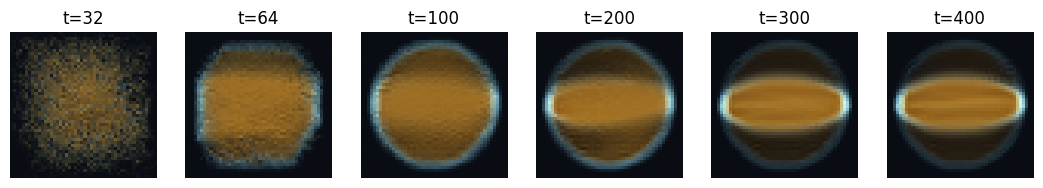

In [8]:
import torch
from nca.model import DiatomNCA
from nca.voice import frame_descriptor
from nca.utils import state_to_rgb
import matplotlib.pyplot as plt

m = DiatomNCA(); m.load_state_dict(torch.load('assets/checkpoint_words.pt', map_location='cpu')['state_dict']); m.eval()
torch.manual_seed(0)
x = m.seed(1, SIZE); z = torch.zeros(1, SIZE, SIZE)
rows, snaps = [], {}
with torch.no_grad():
    for t in range(1, 401):
        x = m.update(x, template=z)
        if t in (32, 64, 100, 200, 300, 400):
            d = frame_descriptor(x[0]); rows.append((t, round(d['mass'], 3), round(d['spread'], 3)))
            snaps[t] = state_to_rgb(x[0])
print('step, mass, alive fraction:', rows)
fig, axes = plt.subplots(1, len(snaps), figsize=(2.2 * len(snaps), 2.4))
for ax, (t, im) in zip(axes, snaps.items()):
    ax.imshow(im); ax.set_title(f't={t}'); ax.axis('off')
plt.show()

## Export and download

`web/weights.js` is what the desktop window loads (`electron/renderer/index.html`). Drop the files into your clone:

```
assets/checkpoint_words.pt
web/weights.js
web/weights.json
```

then `cd electron && npm start`.

In [9]:
!python scripts/export_weights.py --checkpoint assets/checkpoint_words.pt --out web/weights.json
!zip -q -j /content/diatom_words.zip assets/checkpoint_words.pt web/weights.js web/weights.json assets/words.gif assets/demo/words_strip.png
!ls -la /content/diatom_words.zip
from google.colab import files
files.download('/content/diatom_words.zip')

exported web/weights.json (224 KB)
exported web/weights.js (224 KB)
-rw-r--r-- 1 root root 603942 Sep 22 16:39 /content/diatom_words.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Optional: keep a copy on Drive.

In [10]:
SAVE_TO_DRIVE = False  #@param {type:"boolean"}
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    !mkdir -p /content/drive/MyDrive/diatom && cp /content/diatom_words.zip /content/drive/MyDrive/diatom/
    print('saved to Drive: diatom/diatom_words.zip')

## Going further

- **Phrases instead of words**: train with `SIZE = 96` (more steps; `--rollout-max 96`), set `SIZE = 96` in `electron/renderer/app.js`, and raise `MAX_LINE` in `nca/glyph.py` and `electron/renderer/glyph.js` together.
- **Your own lexicon**: edit `LEXICON` in `nca/glyph.py`; the persona's words are what the body practises.
- **Longer holds**: `MORPH_STEPS` / `HOLD_STEPS` in `app.js` set how long each word stands.
